In [1]:
import math
import warnings
from typing import Tuple, Any, Dict

import jax
from jax import numpy as jnp

from matplotlib import pyplot as plt

from blueprint.systems import Transmon, Resonator
from blueprint.couplings import ChargeCoupling
from blueprint.branches.quantum import get_branches
from blueprint.util.quantum import expectation_value

In [2]:
def get_figsize(
    columns: int = 1,
    fig_width: float | None = None,
    fig_height: float | None = None,
    width_scale: float = 1.0,
    height_scale: float = 1.0,
) -> Tuple[float, float]:
    """
    get_figsize Returns the figure size for a matplotlib plot that is
    consistent with the IEEE journal template.

    Parameters
    ----------
    columns : int, optional
        The number of text columns that the figure takes up, by default 1
    fig_width : float | None, optional
        The width of the figure in inches, by default None
    fig_height : float | None, optional
        The height of the figure in inches, by default None
    width_scale : float, optional
        A scale factor for the width of the figure, by default 1.0
    height_scale : float, optional
        A scale factor for the height of the figure, by default 1.0

    Returns
    -------
    Tuple[float, float]
        The width and height of the figure in inches.

    Raises
    ------
    ValueError
        If the number of columns is not 1 or 2.
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    if columns not in [1, 2]:
        raise ValueError("Plotting in three-column style is not supported")

    max_height = 8.0
    golden_ratio = 0.5 * (1 + math.sqrt(5))

    if not fig_width:
        fig_width = 3.4 if columns == 1 else 7
    # one-column width is ~8.6cm, double-column is ~17.8cm

    fig_height = fig_height or fig_width / golden_ratio  # height in inches

    if fig_height > max_height:
        warnings.warn(
            f"Figure height {fig_height} is too large, setting to {max_height}"
            "inches instead"
        )

    width = fig_width * width_scale
    height = fig_height * height_scale
    figsize = (width, height)
    return figsize


def get_rc_params(**kwargs: Any) -> Dict[str, Any]:
    """
    get_rc_params Returns the matplotlib rcParams for a plot that is consistent with the IEEE journal template.

    Parameters
    ----------
    **kwargs : Any
        Additional keyword arguments to pass to the rcParams. These will override the default values.
        The arguments that have pre-defined values are:
        - "axes.labelsize": 8
        - "axes.titlesize": 8
        - "legend.fontsize": 8
        - "xtick.labelsize": 8
        - "ytick.labelsize": 8
        - "text.usetex": False
        - "font.family": "serif"

    Returns
    -------
    Dict[str, Any]
        The dictionary of rcParams for the plot.
    """
    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf
    params = {
        # "backend": "ps", # Commented out because of backened issues
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "text.usetex": False,  # This should ideally be True, but leads to issues in certain cases.
        "font.family": "serif",
    }
    params.update(kwargs)
    return params

In [3]:
USE_DOUBLE_PRECISION: bool = True
USE_GPU: bool = False
DEVICE_IND: int = 0

if USE_DOUBLE_PRECISION:
    jax.config.update("jax_enable_x64", True)  # Double precision

if USE_GPU:
    cuda_devices = jax.devices("cuda")
    if not cuda_devices:
        raise ValueError("No GPU devices found.")

    device = cuda_devices[DEVICE_IND]
    jax.config.update("jax_default_device", device)

In [4]:
# units
GHZ = 2 * math.pi
MHZ = 2 * 1e-3 * math.pi

In [5]:
QUBIT_LABEL: str = "transmon"
CHARGING_ENERGY: float = 220 * MHZ
ENERGY_RATIO: float = 110
JOSEPHSON_ENERGY: float = ENERGY_RATIO * CHARGING_ENERGY
OFFSET_CHARGE: float = 0.0
CHARGE_CUTOFF: int = 500
TRANSMON_DIM: int = 30

transmon = Transmon(
    label=QUBIT_LABEL,
    charging_energy=CHARGING_ENERGY,
    josephson_energy=JOSEPHSON_ENERGY,
    offset_charge=OFFSET_CHARGE,
    charge_cutoff=CHARGE_CUTOFF,
    dim=TRANSMON_DIM,
)

In [6]:
RES_LABEL: str = "resonator"
RES_FREQ: float = 7.5 * GHZ
RES_IMPEDANCE: float = 50.0
RES_DIM: int = 200

resonator = Resonator.from_frequency(
    label=RES_LABEL,
    frequency=RES_FREQ,
    impedance=RES_IMPEDANCE,
    dim=RES_DIM,
)

In [7]:
DEVICE_DIMS = (TRANSMON_DIM, RES_DIM)
DIM = TRANSMON_DIM * RES_DIM

In [8]:
COUP_LABEL: str = "coupling"
COUP_STRENGTH: float = 120 * MHZ

In [9]:
norm_coup_strength = COUP_STRENGTH / resonator.charge_zpf

coupling = ChargeCoupling(
    label=COUP_LABEL,
    strength=norm_coup_strength,
)

In [10]:
_, transmon_states = transmon.get_eigenstates()
_, res_states = resonator.get_eigenstates()
res_ground_state = res_states[:, 0]

prod_states = jnp.kron(transmon_states, res_ground_state[:, None])

In [11]:
transmon = transmon.embed(0, DEVICE_DIMS)
resonator = resonator.embed(1, DEVICE_DIMS)

In [12]:
transmon_hamiltonian = transmon.get_hamiltonian()
resonator_hamiltonian = resonator.get_hamiltonian()
coupling_hamiltonian = coupling.get_hamiltonian(transmon, resonator)

hamiltonian = transmon_hamiltonian + resonator_hamiltonian + coupling_hamiltonian

In [13]:
raise_op = resonator.get_raise_op()

In [14]:
energies, branches = get_branches(
    hamiltonian=hamiltonian, raise_op=raise_op, prod_states=prod_states
)

In [15]:
resonator_number_op = resonator.get_number_op()
res_populations = jnp.real(expectation_value(branches, resonator_number_op))

transmon_number_op = transmon.get_number_op()
transmon_populations = jnp.real(expectation_value(branches, transmon_number_op))

In [16]:
energies = energies.reshape(TRANSMON_DIM, RES_DIM)
res_populations = res_populations.reshape(TRANSMON_DIM, RES_DIM)
transmon_populations = transmon_populations.reshape(TRANSMON_DIM, RES_DIM)

In [17]:
offset = 0.45 * RES_FREQ
modular_energies = ((energies + offset) % RES_FREQ) - offset

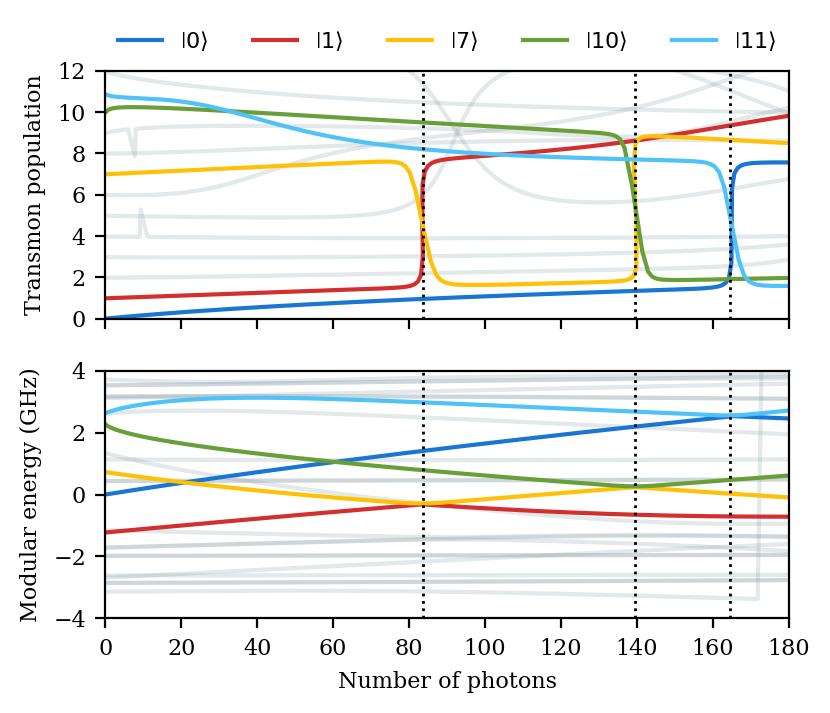

In [ ]:
figsize = get_figsize(height_scale=1.75, width_scale=1.25)
# Use the recommended figure size for two-column figures
rc_params = get_rc_params()  # Use the recommended rc params

highlighted_states = (0, 1, 7, 10, 11)
colors = ["#1976d2", "#d32f2f", "#ffc107", "#689f38", "#4fc3f7"]
default_color = "#90a4ae"

resonance_populations = (83.6, 139.6, 164.6)  
# Resonator populations at which resonances occur
num_states = 25  # How many states to plot
states = tuple(range(num_states + 1))
background_states = (state for state in states if state not in highlighted_states)
with plt.rc_context(rc=rc_params):
    fig, axs = plt.subplots(
        nrows=2, sharex=True, figsize=figsize, tight_layout=True, dpi=200
    )
    population_ax, energy_ax = axs

    for state in background_states:
        population_ax.plot(
            res_populations[state],
            transmon_populations[state],
            color=default_color,
            alpha=0.25,
        )
        energy_ax.plot(
            res_populations[state],
            modular_energies[state] / GHZ,
            color=default_color,
            alpha=0.25,
        )

    for state in highlighted_states:
        state_ind = highlighted_states.index(state)
        color = colors[state_ind]
        label = f"$\\left\\vert {{{state}}} \\right\\rangle$"

        population_ax.plot(
            res_populations[state],
            transmon_populations[state],
            color=color,
            label=label,
        )
        energy_ax.plot(
            res_populations[state],
            modular_energies[state] / GHZ,
            color=color,
            label=label,
        )

    for res_population in resonance_populations:
        population_ax.axvline(res_population, color="black", linestyle=":", linewidth=1)
        energy_ax.axvline(res_population, color="black", linestyle=":", linewidth=1)

    population_ax.legend(
        ncols=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.25)
    )

    population_ax.set_ylim(0, 12)
    population_ax.set_yticks([0, 2, 4, 6, 8, 10, 12])
    population_ax.set_ylabel(r"Transmon population")

    energy_ax.set_ylim(-4, 4)
    energy_ax.set_yticks([-4, -2, 0, 2, 4])
    energy_ax.set_ylabel(r"Modular energy (GHz)")

    energy_ax.set_xlim(0, 180)
    energy_ax.set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])
    energy_ax.set_xlabel(r"Number of photons")

plt.show()